# ML подход

**Идея**

Создать набор признаков на основе имеющихся данных и передать на вход `catboost`

## Data & Libs

In [2]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from pandas import IndexSlice as idx
from sklearn.metrics import mean_absolute_error

df = pd.read_csv(r"..\data\df_tickers.csv", header=[0, 1], index_col=0).sort_index(axis=1)
df.index = pd.to_datetime(df.index, format="%Y-%m-%d")

ts_df: pd.DataFrame = df.loc[:, idx[:, "close"]].dropna().droplevel(level=1, axis=1)

rate = pd.read_pickle("../data/rate.pkl")["CB"]

curr = pd.read_csv("../data/currencies.csv", index_col=0)
curr.index = curr.index.str.extract(r"(\d{4}-\d{2}-\d{2})")[0]
curr.index.name = "date"
curr.index = pd.to_datetime(curr.index, format="%Y-%m-%d")

df_futures: pd.DataFrame = pd.read_pickle("../data/df_futures.pkl") \
    .dropna() \
    .rename({"TRADEDATE": "date", "CLOSE": "BR"}, axis=1)
df_futures = df_futures.loc[df_futures.groupby("date")["delta_days"].idxmin()]
df_futures = df_futures.set_index("date")["BR"]

res_df = ts_df \
    .merge(rate, "left", left_index=True, right_index=True) \
    .merge(curr, "left", left_index=True, right_index=True) \
    .merge(df_futures, "left", left_index=True, right_index=True)

In [3]:
data = res_df.copy()
data = data.interpolate(method="linear", limit_direction="forward", limit_area="inside", limit=3)

target_col = "LKOH"
feature_cols = ["rate", "Доллар", "Евро", "Юань", "BR"]

## Временные признаки

In [4]:
def create_time_features(
    df: pd.DataFrame,
    return_new_colnames: bool = True,
    exclude: str | list | None = "dayofweek"
):
    df_cols = df.columns
    df = df.copy()

    # Основные временные признаки
    df["year"] = df.index.year
    df["month"] = df.index.month
    df["dayofweek"] = df.index.dayofweek
    df["quarter"] = df.index.quarter
    df["days_since_start"] = (df.index - df.index.min()).days

    # Синус и косинус для цикличных признаков (месяцы, дни недели)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["dayofweek_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dayofweek_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

    if exclude is not None:
        df = df.drop(exclude, axis=1)

    if return_new_colnames:
        return df, df.columns.difference(df_cols).to_list()
    return df


data_features, time_features = create_time_features(data)

## Основные признаки на основе таргета

In [5]:
import time
from collections import defaultdict

from scipy import stats

n_lags = 30
ma_windows = (7, 14, 30)
ewm_windows = (7, 14, 30)
vol_windows = (7, 14, 30)


def create_extended_features(
    df: pd.DataFrame,
    target_column: str,
    n_lags: int = n_lags,
    ma_windows: tuple | list = ma_windows,
    ewm_windows: tuple | list = ewm_windows,
    vol_windows: tuple | list = vol_windows,
    return_new_colnames: bool = True,
    verbose: bool = True
) -> pd.DataFrame | tuple[pd.DataFrame, list]:
    """
    Создает расширенные финансовые признаки для целевого столбца.
    """
    # Словарь для хранения времени выполнения каждой секции
    timings = defaultdict(float)

    # Вспомогательная функция для замера времени
    def time_section(section_name, func, *args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        elapsed = time.time() - start_time
        timings[section_name] += elapsed
        return result

    total_start_time = time.time()

    original_cols = df.columns.tolist()
    base_df = df.copy()

    all_features = {}

    # Lag features
    def create_lag_features():
        lag_dfs = {}
        for lag in range(1, n_lags + 1):
            lag_dfs[f"{target_column}_lag_{lag}"] = base_df[target_column].shift(lag)
        return lag_dfs
    all_features.update(time_section("Lag features", create_lag_features))

    # Moving averages
    def create_ma_features():
        ma_dfs = {}
        for window in ma_windows:
            ma_dfs[f"{target_column}_ma_{window}"] = base_df[target_column].rolling(window=window, closed="left").mean()
        return ma_dfs
    ma_dfs = time_section("Moving averages (MA)", create_ma_features)
    all_features.update(ma_dfs)

    # Exponential moving averages
    def create_ewm_features():
        ewm_dfs = {}
        for window in ewm_windows:
            ewm_dfs[f"{target_column}_ema_{window}"] = base_df[target_column].ewm(span=window, adjust=False).mean()
        return ewm_dfs
    ewm_dfs = time_section("Exponential moving averages (EMA)", create_ewm_features)
    all_features.update(ewm_dfs)

    # Volatility
    def create_vol_features():
        vol_dfs = {}
        for window in vol_windows:
            vol_dfs[f"{target_column}_vol_{window}"] = base_df[target_column].rolling(window=window, closed="left").std()
        return vol_dfs
    vol_dfs = time_section("Volatility", create_vol_features)
    all_features.update(vol_dfs)

    # Percent changes
    def create_pct_change_features():
        pct_change_dfs = {}
        for lag in range(1, 6):
            pct_change_dfs[f"{target_column}_pct_change_{lag}"] = base_df[target_column].pct_change(periods=lag)
        return pct_change_dfs
    all_features.update(time_section("Percent changes", create_pct_change_features))

    # Rate of change
    def create_roc_features():
        roc_dfs = {}
        for window in ma_windows:
            roc_dfs[f"{target_column}_roc_{window}"] = (base_df[target_column] - base_df[target_column].shift(window)) / base_df[target_column].shift(window) * 100
        return roc_dfs
    all_features.update(time_section("Rate of change", create_roc_features))

    # Momentum indicators
    def create_momentum_features():
        momentum_dfs = {}
        for window in ma_windows:
            momentum_dfs[f"{target_column}_momentum_{window}"] = base_df[target_column] - base_df[target_column].shift(window)
        return momentum_dfs
    all_features.update(time_section("Momentum indicators", create_momentum_features))

    # RSI (Relative Strength Index)
    def create_rsi_features():
        rsi_dfs = {}
        delta = base_df[target_column].diff()
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)

        for window in (14, 21):
            avg_gain = gain.rolling(window=window, closed="left").mean()
            avg_loss = loss.rolling(window=window, closed="left").mean()
            rs = avg_gain / avg_loss
            rsi_dfs[f"{target_column}_rsi_{window}"] = 100 - (100 / (1 + rs))
        return rsi_dfs
    all_features.update(time_section("RSI", create_rsi_features))

    # MACD (Moving Average Convergence Divergence)
    def create_macd_features():
        macd_dfs = {}
        ema_12 = base_df[target_column].ewm(span=12, adjust=False).mean()
        ema_26 = base_df[target_column].ewm(span=26, adjust=False).mean()
        macd = ema_12 - ema_26
        macd_signal = macd.ewm(span=9, adjust=False).mean()

        macd_dfs[f"{target_column}_macd"] = macd
        macd_dfs[f"{target_column}_macd_signal"] = macd_signal
        macd_dfs[f"{target_column}_macd_hist"] = macd - macd_signal
        return macd_dfs
    all_features.update(time_section("MACD", create_macd_features))

    # Bollinger Bands
    def create_bb_features():
        bb_dfs = {}
        for window in ma_windows:
            ma_series = ma_dfs[f"{target_column}_ma_{window}"]
            vol_series = vol_dfs[f"{target_column}_vol_{window}"]

            bb_upper = ma_series + 2 * vol_series
            bb_lower = ma_series - 2 * vol_series
            bb_width = (bb_upper - bb_lower) / ma_series
            bb_pct = (base_df[target_column] - bb_lower) / (bb_upper - bb_lower)

            bb_dfs[f"{target_column}_bb_upper_{window}"] = bb_upper
            bb_dfs[f"{target_column}_bb_lower_{window}"] = bb_lower
            bb_dfs[f"{target_column}_bb_width_{window}"] = bb_width
            bb_dfs[f"{target_column}_bb_pct_{window}"] = bb_pct
        return bb_dfs
    all_features.update(time_section("Bollinger Bands", create_bb_features))

    # Statistical features
    def create_stat_features():
        stat_dfs = {}
        for window in [30]:
            # Skewness
            stat_dfs[f"{target_column}_skew_{window}"] = base_df[target_column].rolling(window=window, closed="left").apply(lambda x: stats.skew(x))
            # Kurtosis
            stat_dfs[f"{target_column}_kurt_{window}"] = base_df[target_column].rolling(window=window, closed="left").apply(lambda x: stats.kurtosis(x))
            # Max, Min, Range
            rolling_max = base_df[target_column].rolling(window=window, closed="left").max()
            rolling_min = base_df[target_column].rolling(window=window, closed="left").min()

            stat_dfs[f"{target_column}_max_{window}"] = rolling_max
            stat_dfs[f"{target_column}_min_{window}"] = rolling_min
            stat_dfs[f"{target_column}_range_{window}"] = rolling_max - rolling_min

            # Quantiles
            q25 = base_df[target_column].rolling(window=window, closed="left").quantile(0.25)
            q75 = base_df[target_column].rolling(window=window, closed="left").quantile(0.75)

            stat_dfs[f"{target_column}_q25_{window}"] = q25
            stat_dfs[f"{target_column}_q75_{window}"] = q75
            stat_dfs[f"{target_column}_iqr_{window}"] = q75 - q25
        return stat_dfs
    all_features.update(time_section("Statistical features", create_stat_features))

    # Z-score
    def create_zscore_features():
        zscore_dfs = {}
        for window in ma_windows:
            zscore_dfs[f"{target_column}_zscore_{window}"] = (base_df[target_column] - ma_dfs[f"{target_column}_ma_{window}"]) / vol_dfs[f"{target_column}_vol_{window}"]
        return zscore_dfs
    all_features.update(time_section("Z-score", create_zscore_features))

    # Distance from MA
    def create_dist_features():
        dist_dfs = {}
        for window in ma_windows:
            ma_series = ma_dfs[f"{target_column}_ma_{window}"]
            dist_dfs[f"{target_column}_dist_ma_{window}"] = base_df[target_column] - ma_series
            dist_dfs[f"{target_column}_dist_pct_ma_{window}"] = (base_df[target_column] / ma_series - 1) * 100
        return dist_dfs
    all_features.update(time_section("Distance from MA", create_dist_features))

    # Crossovers
    def create_cross_features():
        cross_dfs = {}
        for fast_window, slow_window in [(7, 14), (14, 30)]:
            if f"{target_column}_ma_{fast_window}" in ma_dfs and f"{target_column}_ma_{slow_window}" in ma_dfs:
                cross_dfs[f"{target_column}_cross_{fast_window}_{slow_window}"] = ma_dfs[f"{target_column}_ma_{fast_window}"] - ma_dfs[f"{target_column}_ma_{slow_window}"]
        return cross_dfs
    all_features.update(time_section("Crossovers", create_cross_features))

    # Williams %R
    def create_williams_features():
        williams_dfs = {}
        for window in ma_windows:
            highest_high = base_df[target_column].rolling(window=window, closed="left").max()
            lowest_low = base_df[target_column].rolling(window=window, closed="left").min()
            williams_dfs[f"{target_column}_williams_{window}"] = -100 * (highest_high - base_df[target_column]) / (highest_high - lowest_low)
        return williams_dfs
    all_features.update(time_section("Williams %R", create_williams_features))

    # Smoothed features
    def create_smooth_features():
        smooth_dfs = {}
        for window in ma_windows:
            smooth_dfs[f"{target_column}_ma_of_ma_{window}"] = ma_dfs[f"{target_column}_ma_{window}"].rolling(window=window, closed="left").mean()
            smooth_dfs[f"{target_column}_ema_of_ema_{window}"] = ewm_dfs[f"{target_column}_ema_{window}"].ewm(span=window, adjust=False).mean()
        return smooth_dfs
    all_features.update(time_section("Smoothed features", create_smooth_features))

    # Trend strength
    def create_trend_features():
        trend_dfs = {}
        for window in ma_windows:
            trend_dfs[f"{target_column}_trend_strength_{window}"] = np.abs(ma_dfs[f"{target_column}_ma_{window}"].diff(periods=window)) / vol_dfs[f"{target_column}_vol_{window}"]
        return trend_dfs
    all_features.update(time_section("Trend strength", create_trend_features))

    # Fourier Transform features
    def create_fft_features():
        fft_dfs = {}
        for window in [30, 60]:
            if len(base_df) >= window:
                fft_dfs[f"{target_column}_fft_dominant_{window}"] = base_df[target_column].rolling(window=window, closed="left").apply(
                    lambda x: np.abs(np.fft.fft(x - np.mean(x)))[1:window//2].argmax() + 1 if len(x) == window else np.nan
                )
        return fft_dfs
    all_features.update(time_section("Fourier Transform features", create_fft_features))

    def create_result_df():
        features_df = pd.DataFrame(all_features, index=base_df.index)
        result_df = pd.concat([base_df, features_df], axis=1)
        return result_df, features_df

    result_df, features_df = time_section("Create and concatenate DataFrame", create_result_df)

    total_time = time.time() - total_start_time
    if verbose:
        print(f"Total execution time: {total_time:.4f} сек")
        print("\nОперации, отсортированные по времени выполнения:")
        for section, elapsed in sorted(timings.items(), key=lambda x: x[1], reverse=True):
            print(f"  {section}: {elapsed:.4f} сек ({elapsed/total_time*100:.1f}%)")

    if return_new_colnames:
        new_cols = [col for col in result_df.columns if col not in original_cols]
        return result_df, new_cols
    else:
        return result_df

def update_extended_features_lastrow(
    df: pd.DataFrame,
    target_column: str,
    new_target_value: float,
    n_lags: int = 30,
    ma_windows: tuple | list = (7, 14, 30),
    ewm_windows: tuple | list = (7, 14, 30),
    vol_windows: tuple | list = (7, 14, 30),
) -> pd.DataFrame:
    """
    Обновляет последнюю строку датасета с расширенными признаками, заменяя значение целевой
    переменной на заданное и пересчитывая все признаки, созданные функцией create_extended_features.
    """
    result = df.copy()
    last_index = result.index[-1]
    prev_row_index = result.index[-2]

    # Обновляем значение целевой переменной
    result.loc[last_index, target_column] = new_target_value

    # Lag features
    for lag in range(1, n_lags + 1):
        if lag == 1:
            result.loc[last_index, f"{target_column}_lag_{lag}"] = result.loc[prev_row_index, target_column]
        else:
            result.loc[last_index, f"{target_column}_lag_{lag}"] = result.loc[prev_row_index, f"{target_column}_lag_{lag-1}"]

    # Moving averages
    for window in ma_windows:
        values = result.loc[:prev_row_index, target_column].iloc[-(window-1):].values
        if len(values) == window-1:
            ma_value = (np.sum(values) + new_target_value) / window
            result.loc[last_index, f"{target_column}_ma_{window}"] = ma_value

    # Exponential moving averages
    for window in ewm_windows:
        alpha = 2 / (window + 1)
        prev_ema = result.loc[prev_row_index, f"{target_column}_ema_{window}"]
        new_ema = alpha * new_target_value + (1 - alpha) * prev_ema
        result.loc[last_index, f"{target_column}_ema_{window}"] = new_ema

    # Volatility
    for window in vol_windows:
        values = result.loc[:prev_row_index, target_column].iloc[-(window-1):].values
        if len(values) == window-1:
            full_window = np.append(values, new_target_value)
            vol_value = np.std(full_window, ddof=1)
            result.loc[last_index, f"{target_column}_vol_{window}"] = vol_value

    # Percent changes
    for lag in range(1, 6):
        prev_value = result.loc[prev_row_index, target_column] if lag == 1 else result.loc[prev_row_index, f"{target_column}_lag_{lag-1}"]
        if prev_value != 0:
            pct_change = (new_target_value - prev_value) / prev_value if lag == 1 else result.loc[prev_row_index, f"{target_column}_pct_change_{lag-1}"]
            result.loc[last_index, f"{target_column}_pct_change_{lag}"] = pct_change

    # Rate of change
    for window in ma_windows:
        window_value = result.loc[prev_row_index, f"{target_column}_lag_{window-1}"] if window <= n_lags else result.loc[:prev_row_index, target_column].shift(window-1).iloc[-1]
        if window_value != 0:
            roc = (new_target_value - window_value) / window_value * 100
            result.loc[last_index, f"{target_column}_roc_{window}"] = roc

    # Momentum indicators
    for window in ma_windows:
        window_value = result.loc[prev_row_index, f"{target_column}_lag_{window-1}"] if window <= n_lags else result.loc[:prev_row_index, target_column].shift(window-1).iloc[-1]
        momentum = new_target_value - window_value
        result.loc[last_index, f"{target_column}_momentum_{window}"] = momentum

    # RSI (Relative Strength Index)
    for window in (14, 21):
        delta = new_target_value - result.loc[prev_row_index, target_column]
        gain = max(0, delta)
        loss = max(0, -delta)

        # Получаем предыдущие средние приросты и убытки
        prev_rows = result.iloc[-(window+1):-1]  # Берем window предыдущих строк
        prev_deltas = prev_rows[target_column].diff().iloc[1:]  # Пропускаем первую NaN
        prev_gains = prev_deltas.clip(lower=0)
        prev_losses = -prev_deltas.clip(upper=0)

        if len(prev_rows) >= window:
            # Если есть достаточно предыдущих строк
            prev_avg_gain = result.loc[prev_row_index, f"{target_column}_rsi_{window}_avgain"] if f"{target_column}_rsi_{window}_avgain" in result.columns else prev_gains.mean()
            prev_avg_loss = result.loc[prev_row_index, f"{target_column}_rsi_{window}_avloss"] if f"{target_column}_rsi_{window}_avloss" in result.columns else prev_losses.mean()

            avg_gain = (prev_avg_gain * (window - 1) + gain) / window
            avg_loss = (prev_avg_loss * (window - 1) + loss) / window

            result.loc[last_index, f"{target_column}_rsi_{window}_avgain"] = avg_gain
            result.loc[last_index, f"{target_column}_rsi_{window}_avloss"] = avg_loss
        else:
            # Если недостаточно данных, используем простое среднее
            avg_gain = (prev_gains.sum() + gain) / max(1, len(prev_gains))
            avg_loss = (prev_losses.sum() + loss) / max(1, len(prev_losses))

        if avg_loss == 0:
            rsi = 100
        else:
            rs = avg_gain / avg_loss
            rsi = 100 - (100 / (1 + rs))

        result.loc[last_index, f"{target_column}_rsi_{window}"] = rsi

    # MACD (Moving Average Convergence Divergence)
    ema_12 = result.loc[last_index, f"{target_column}_ema_12"] if f"{target_column}_ema_12" in result.columns else new_target_value * 0.15 + result.loc[prev_row_index, target_column] * 0.85
    ema_26 = result.loc[last_index, f"{target_column}_ema_26"] if f"{target_column}_ema_26" in result.columns else new_target_value * 0.07 + result.loc[prev_row_index, target_column] * 0.93

    macd = ema_12 - ema_26
    result.loc[last_index, f"{target_column}_macd"] = macd

    prev_macd_signal = result.loc[prev_row_index, f"{target_column}_macd_signal"]
    macd_signal = macd * 0.2 + prev_macd_signal * 0.8
    result.loc[last_index, f"{target_column}_macd_signal"] = macd_signal

    macd_hist = macd - macd_signal
    result.loc[last_index, f"{target_column}_macd_hist"] = macd_hist

    # Bollinger Bands
    for window in ma_windows:
        ma_value = result.loc[last_index, f"{target_column}_ma_{window}"]
        vol_value = result.loc[last_index, f"{target_column}_vol_{window}"]

        bb_upper = ma_value + 2 * vol_value
        bb_lower = ma_value - 2 * vol_value
        bb_width = (bb_upper - bb_lower) / ma_value if ma_value != 0 else 0
        bb_pct = (new_target_value - bb_lower) / (bb_upper - bb_lower) if (bb_upper - bb_lower) != 0 else 0.5

        result.loc[last_index, f"{target_column}_bb_upper_{window}"] = bb_upper
        result.loc[last_index, f"{target_column}_bb_lower_{window}"] = bb_lower
        result.loc[last_index, f"{target_column}_bb_width_{window}"] = bb_width
        result.loc[last_index, f"{target_column}_bb_pct_{window}"] = bb_pct

    # Statistical features
    for window in [30]:
        values = np.append(result.loc[:prev_row_index, target_column].iloc[-(window-1):].values, new_target_value)

        if len(values) == window:
            # Скошенность (Skewness)
            skew = stats.skew(values)
            result.loc[last_index, f"{target_column}_skew_{window}"] = skew

            # Эксцесс (Kurtosis)
            kurt = stats.kurtosis(values)
            result.loc[last_index, f"{target_column}_kurt_{window}"] = kurt

            # Максимум, минимум, размах
            rolling_max = np.max(values)
            rolling_min = np.min(values)

            result.loc[last_index, f"{target_column}_max_{window}"] = rolling_max
            result.loc[last_index, f"{target_column}_min_{window}"] = rolling_min
            result.loc[last_index, f"{target_column}_range_{window}"] = rolling_max - rolling_min

            # Квантили
            q25 = np.percentile(values, 25)
            q75 = np.percentile(values, 75)

            result.loc[last_index, f"{target_column}_q25_{window}"] = q25
            result.loc[last_index, f"{target_column}_q75_{window}"] = q75
            result.loc[last_index, f"{target_column}_iqr_{window}"] = q75 - q25

    # Z-score
    for window in ma_windows:
        ma_value = result.loc[last_index, f"{target_column}_ma_{window}"]
        vol_value = result.loc[last_index, f"{target_column}_vol_{window}"]

        if vol_value != 0:
            zscore = (new_target_value - ma_value) / vol_value
            result.loc[last_index, f"{target_column}_zscore_{window}"] = zscore

    # Distance from MA
    for window in ma_windows:
        ma_value = result.loc[last_index, f"{target_column}_ma_{window}"]

        dist = new_target_value - ma_value
        dist_pct = (new_target_value / ma_value - 1) * 100 if ma_value != 0 else 0

        result.loc[last_index, f"{target_column}_dist_ma_{window}"] = dist
        result.loc[last_index, f"{target_column}_dist_pct_ma_{window}"] = dist_pct

    # Crossovers
    for fast_window, slow_window in [(7, 14), (14, 30)]:
        if f"{target_column}_ma_{fast_window}" in result.columns and f"{target_column}_ma_{slow_window}" in result.columns:
            fast_ma = result.loc[last_index, f"{target_column}_ma_{fast_window}"]
            slow_ma = result.loc[last_index, f"{target_column}_ma_{slow_window}"]
            cross = fast_ma - slow_ma
            result.loc[last_index, f"{target_column}_cross_{fast_window}_{slow_window}"] = cross

    # Williams %R
    for window in ma_windows:
        values = np.append(result.loc[:prev_row_index, target_column].iloc[-(window-1):].values, new_target_value)

        if len(values) == window:
            highest_high = np.max(values)
            lowest_low = np.min(values)

            if highest_high != lowest_low:
                williams_r = -100 * (highest_high - new_target_value) / (highest_high - lowest_low)
                result.loc[last_index, f"{target_column}_williams_{window}"] = williams_r

    # Smoothed features
    for window in ma_windows:
        ma_values = result.loc[:prev_row_index, f"{target_column}_ma_{window}"].iloc[-(window-1):].values
        if len(ma_values) == window-1:
            current_ma = result.loc[last_index, f"{target_column}_ma_{window}"]
            ma_of_ma = (np.sum(ma_values) + current_ma) / window
            result.loc[last_index, f"{target_column}_ma_of_ma_{window}"] = ma_of_ma

        prev_ema_of_ema = result.loc[prev_row_index, f"{target_column}_ema_of_ema_{window}"]
        current_ema = result.loc[last_index, f"{target_column}_ema_{window}"]
        alpha = 2 / (window + 1)
        ema_of_ema = alpha * current_ema + (1 - alpha) * prev_ema_of_ema
        result.loc[last_index, f"{target_column}_ema_of_ema_{window}"] = ema_of_ema

    # Trend strength
    for window in ma_windows:
        if f"{target_column}_ma_{window}" in result.columns:
            window_index = None
            try:
                current_pos = result.index.get_loc(last_index)
                if current_pos >= window:
                    window_index = result.index[current_pos - window]
            except Exception as e:
                print(f"Trend strength error: {e}")

            if window_index is not None and window_index in result.index:
                previous_ma = result.loc[window_index, f"{target_column}_ma_{window}"]
                current_ma = result.loc[last_index, f"{target_column}_ma_{window}"]
                ma_diff = current_ma - previous_ma

                vol_value = result.loc[last_index, f"{target_column}_vol_{window}"]
                if vol_value != 0:
                    trend_strength = abs(ma_diff) / vol_value
                    result.loc[last_index, f"{target_column}_trend_strength_{window}"] = trend_strength
                else:
                    result.loc[last_index, f"{target_column}_trend_strength_{window}"] = np.nan
            else:
                result.loc[last_index, f"{target_column}_trend_strength_{window}"] = np.nan
        else:
            result.loc[last_index, f"{target_column}_trend_strength_{window}"] = np.nan

    # Fourier Transform features
    for window in [30, 60]:
        if len(result) >= window:
            values = np.append(result.loc[:prev_row_index, target_column].iloc[-(window-1):].values, new_target_value)
            if len(values) == window:
                # Удаляем среднее значение для лучшего анализа частот
                values_centered = values - np.mean(values)
                # Вычисляем FFT
                fft_values = np.abs(np.fft.fft(values_centered))
                # Определяем доминирующую частоту (первую половину спектра без постоянной составляющей)
                dominant_freq = fft_values[1:window//2].argmax() + 1
                result.loc[last_index, f"{target_column}_fft_dominant_{window}"] = dominant_freq

    return result


df_features_ext, _ = create_extended_features(data_features, "LKOH", verbose=True)
df_features_ext = df_features_ext.dropna()
df_features_ext_lite = df_features_ext.drop(["ROSN", "SIBN", "SNGS", "TATN", "rate", "Доллар", "Евро", "Юань", "BR"], axis=1)

Total execution time: 3.8975 сек

Операции, отсортированные по времени выполнения:
  Statistical features: 2.9008 сек (74.4%)
  Fourier Transform features: 0.9792 сек (25.1%)
  Williams %R: 0.0030 сек (0.1%)
  Lag features: 0.0020 сек (0.1%)
  RSI: 0.0020 сек (0.1%)
  Create and concatenate DataFrame: 0.0020 сек (0.1%)
  MACD: 0.0015 сек (0.0%)
  Bollinger Bands: 0.0010 сек (0.0%)
  Percent changes: 0.0010 сек (0.0%)
  Distance from MA: 0.0010 сек (0.0%)
  Smoothed features: 0.0010 сек (0.0%)
  Exponential moving averages (EMA): 0.0010 сек (0.0%)
  Volatility: 0.0010 сек (0.0%)
  Rate of change: 0.0010 сек (0.0%)
  Moving averages (MA): 0.0000 сек (0.0%)
  Momentum indicators: 0.0000 сек (0.0%)
  Z-score: 0.0000 сек (0.0%)
  Crossovers: 0.0000 сек (0.0%)
  Trend strength: 0.0000 сек (0.0%)


## Модель

Есть 2 подхода к прогнозированию:
- Итеративный: с помощью одной модели предсказываем следующее значение целевой, обновляем признаки - базовый вариант - перенести с предыдущей строки. И так повторяем нужное число шагов.
- С заменой таргета: обучаем модель, которая предсказывает (t+1), делаем предсказание для последней строки валидации, тем самым получаем прогноз на первую строку тестовой выборки. Далее двигаем таргет на 1 шаг, переобучаем модель и повторяем так пока не спрогнозируем все шаги.

### Итеративный прогноз

In [5]:
# df = df_features_ext.copy()
df = df_features_ext_lite.copy()

# Выбираем train и test
train_size = 1000
val_size = int(train_size * 0.1)
test_size = 100

## Для проверки конкретного прогноза (split_point):
# split_point = 3474
# test_size = 10
# val_size = int((split_point - test_size) * 0.1)
# train_size = (split_point - val_size - test_size)

train_data = df.iloc[:train_size-val_size]
val_data = df.iloc[train_size-val_size:train_size]
test_data = df.iloc[train_size:train_size+test_size]

# Определение целевой переменной и признаков
X_train = train_data.drop("LKOH", axis=1)
y_train = train_data["LKOH"]
X_val = val_data.drop("LKOH", axis=1)
y_val = val_data["LKOH"]
X_test = test_data.drop("LKOH", axis=1)
y_test = test_data["LKOH"]

# Обучение модели CatBoost
model = CatBoostRegressor(
    iterations=3000,                # Увеличиваем число итераций для лучшего результата
    learning_rate=0.05,             # Снижаем скорость обучения для повышения качества
    depth=8,                        # Немного увеличиваем глубину (6 → 8)
    l2_leaf_reg=5,                  # Регуляризация для уменьшения переобучения
    loss_function="RMSE",           # MAE устойчив к выбросам
    eval_metric="MAE",
    early_stopping_rounds=200,      # Если нет улучшения за 200 итераций, обучение останавливается
    random_seed=42,                 # Фиксируем сид
    boosting_type="Plain",          # Обычный бустинг
    grow_policy="Lossguide",        # Адаптивное разрастание (для сложных зависимостей)
    random_strength=5,              # Добавляем шум в разбиение для уменьшения переобучения
    leaf_estimation_iterations=20,  # Улучшаем веса в листьях
    verbose=400                     # Вывод логов каждые 400 итераций
)

model = model.fit(X_train, y_train, eval_set=(X_val, y_val))

0:	learn: 174.4923085	test: 219.6894376	best: 219.6894376 (0)	total: 153ms	remaining: 7m 37s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 7.999841977
bestIteration = 175

Shrink model to first 176 iterations.


`Once done` - не совсем честные предсказания, поскольку там используются реальные экзогенные переменные за будущие периоды, которые на самом деле нам известны не будут  
(не знаю почему так назвал это...)  
`Stepwise` - использует копирование последних известных данных (честное пошаговое предсказание)

In [6]:
# Итеративный прогноз на тестовой выборке
forecast_df = pd.concat([train_data, val_data]).copy()

stepwise_pred = []

for step in range(len(test_data)):
    last_row = forecast_df.iloc[-1:].copy()
    X_last = last_row.drop("LKOH", axis=1)

    predicted_value = model.predict(X_last)[0]
    stepwise_pred.append(predicted_value)

    new_row = last_row.copy()
    new_row.index = [test_data.index[step]]
    new_row.loc[test_data.index[step], time_features] = test_data.loc[test_data.index[step], time_features]
    new_row["LKOH"] = predicted_value

    forecast_df = pd.concat([forecast_df, new_row])
    forecast_df = update_extended_features_lastrow(forecast_df, "LKOH", predicted_value)

once_done_pred = model.predict(X_test)

test_predictions_df = pd.DataFrame(
    {"Predicted (stepwise)": stepwise_pred,
     "Predicted (once done)": once_done_pred,
     "Real": y_test},
    index=test_data.index
)

In [7]:
for window in range(10, len(test_data) + 1, 10):
    mae = mean_absolute_error(y_test.iloc[:window], stepwise_pred[:window])
    print(f"MAE ({window}): {mae:.2f}")

MAE (10): 35.34
MAE (20): 54.45
MAE (30): 47.08
MAE (40): 65.83
MAE (50): 90.81
MAE (60): 101.58
MAE (70): 99.78
MAE (80): 97.45
MAE (90): 99.34
MAE (100): 102.87


<Axes: xlabel='date'>

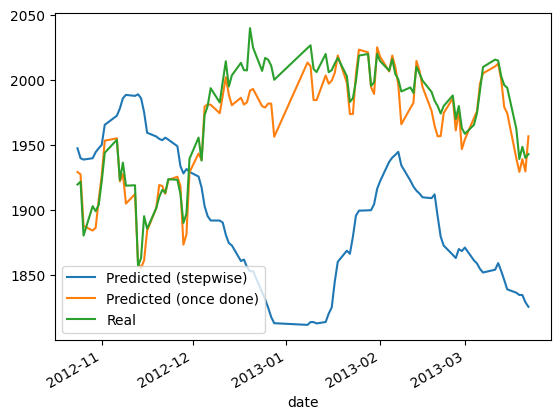

In [8]:
test_predictions_df.plot()

In [9]:
model.get_feature_importance(prettified=True)

,Feature Id,Importances
0,LKOH_ma_of_ma_7,10.679181
1,LKOH_ema_of_ema_7,6.973706
2,LKOH_ema_30,6.692451
3,LKOH_bb_lower_30,6.360358
4,LKOH_bb_lower_7,6.098020
...,...,...
103,LKOH_vol_7,0.010137
104,month,0.008769
105,dayofweek_sin,0.007191
106,LKOH_fft_dominant_60,0.005801


### Обертка в функцию

Это позволит сравнить с `auto arima` подходом

In [10]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error

In [11]:
# Функция для обучения и тестирования модели на случайных разбиениях (с последовательными данными)
def evaluate_catboost_time_series_random_split(
    df: pd.DataFrame,
    target_column: str,
    n_splits: int = 1,  # Количество случайных разбиений
    test_size: int = 10,
    val_ratio: float = 0.1,
    random_state: int = 42
):
    results = []
    min_train_size = 300

    np.random.seed(random_state)
    split_points = np.random.randint(min_train_size, len(df) - test_size, n_splits)

    for i in range(n_splits):
        print(f"\nИтерация {i+1}/{n_splits}")
        split_point = split_points[i]

        train_size = split_point - test_size  # До test идет train + val
        val_size = int(train_size * val_ratio)

        train_data = df.iloc[:train_size-val_size]
        val_data = df.iloc[train_size-val_size:train_size]
        test_data = df.iloc[train_size:train_size+test_size]

        X_train = train_data.drop(target_column, axis=1)
        y_train = train_data[target_column]
        X_val = val_data.drop(target_column, axis=1)
        y_val = val_data[target_column]
        X_test = test_data.drop(target_column, axis=1)
        y_test = test_data[target_column]

        model = CatBoostRegressor(
            iterations=3000,
            learning_rate=0.05,
            depth=8,
            l2_leaf_reg=5,
            loss_function="MAE",
            eval_metric="MAE",
            early_stopping_rounds=200,
            random_seed=random_state,
            boosting_type="Plain",
            grow_policy="Lossguide",
            random_strength=5,
            leaf_estimation_iterations=20,
            verbose=400
        )

        model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=0)

        once_done_pred = model.predict(X_test)

        forecast_df = pd.concat([train_data, val_data]).copy()
        stepwise_pred = []

        for step in range(len(test_data)):
            last_row = forecast_df.iloc[-1:].copy()
            X_last = last_row.drop(target_column, axis=1)
            predicted_value = model.predict(X_last)[0]
            stepwise_pred.append(predicted_value)

            new_row = last_row.copy()
            new_row.index = [test_data.index[step]]
            new_row.loc[test_data.index[step], time_features] = test_data.loc[test_data.index[step], time_features]

            forecast_df = pd.concat([forecast_df, new_row])
            forecast_df = update_extended_features_lastrow(forecast_df, target_column, predicted_value)

        mae_once = mean_absolute_error(y_test, once_done_pred)
        rmse_once = root_mean_squared_error(y_test, once_done_pred)

        mae_stepwise = mean_absolute_error(y_test, stepwise_pred)
        rmse_stepwise = root_mean_squared_error(y_test, stepwise_pred)

        print(f"MAE: once={mae_once:.4f}, stepwise={mae_stepwise:.4f} | RMSE: once={rmse_once:.4f}, stepwise={rmse_stepwise:.4f}")

        results.append({
            "iteration": i + 1,
            "split_point": split_point,
            "train_size": train_size,
            "val_size": val_size,
            "test_size": test_size,
            "mae_once": mae_once,
            "rmse_once": rmse_once,
            "mae_stepwise": mae_stepwise,
            "rmse_stepwise": rmse_stepwise
        })

    results_df = pd.DataFrame(results)
    return results_df

results_df = evaluate_catboost_time_series_random_split(df_features_ext_lite, "LKOH")


Итерация 1/1
MAE: once=64.4719, stepwise=320.8775 | RMSE: once=75.1850, stepwise=341.3048


In [12]:
results_df

,iteration,split_point,train_size,val_size,test_size,mae_once,rmse_once,mae_stepwise,rmse_stepwise
0,1,3474,3464,346,10,64.471881,75.185006,320.877508,341.304798


### Прогноз с изменением таргета (t+1, t+2, ...)

Строим по 1 модели на каждые шаг из прогноза  
Разумеется 100 моделей тут строить невозможно

In [13]:
train_size = 1000
val_size = int(train_size * 0.1)
test_size = 10

models = []
predictions = []

df = df_features_ext_lite.copy()

train_data = df.iloc[:train_size-val_size]
val_data = df.iloc[train_size-val_size:train_size]
test_data = df.iloc[train_size:train_size+test_size]

train_end_idx = train_data.index[-1]
val_end_idx = val_data.index[-1]

for horizon in range(1, test_size + 1):
    print(f"\nОбучение модели для горизонта t+{horizon}:")

    df_horizon = df.copy()
    df_horizon[f"{target_col}_t{horizon}"] = df_horizon[target_col].shift(-horizon)
    df_horizon = df_horizon.dropna()

    df_horizon_features = df_horizon.drop([target_col, f"{target_col}_t{horizon}"], axis=1, errors="ignore")
    df_horizon = pd.concat([df_horizon_features, df_horizon[[f"{target_col}_t{horizon}"]].rename(
        columns={f"{target_col}_t{horizon}": target_col})], axis=1)

    horizon_train_data = df_horizon[df_horizon.index <= train_end_idx]
    horizon_val_data = df_horizon[(df_horizon.index > train_end_idx) & (df_horizon.index <= val_end_idx)]

    X_train = horizon_train_data.drop(target_col, axis=1)
    y_train = horizon_train_data[target_col]
    X_val = horizon_val_data.drop(target_col, axis=1)
    y_val = horizon_val_data[target_col]

    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.05,
        depth=8,
        l2_leaf_reg=5,
        loss_function="MAE",
        eval_metric="MAE",
        early_stopping_rounds=200,
        random_seed=42 + horizon,
        boosting_type="Plain",
        grow_policy="Lossguide",
        random_strength=5,
        leaf_estimation_iterations=20,
        verbose=400
    )

    model = model.fit(X_train, y_train, eval_set=(X_val, y_val))
    models.append(model)

    # Делаем прогноз для последней строки валидации
    last_val_row = X_val.iloc[-1:].copy()
    prediction = model.predict(last_val_row)[0]
    predictions.append(prediction)


Обучение модели для горизонта t+1:
0:	learn: 166.6208141	test: 164.4156434	best: 164.4156434 (0)	total: 15.5ms	remaining: 46.4s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 18.86564624
bestIteration = 167

Shrink model to first 168 iterations.

Обучение модели для горизонта t+2:
0:	learn: 166.0041416	test: 164.8229442	best: 164.8229442 (0)	total: 41.7ms	remaining: 2m 4s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 26.23860592
bestIteration = 142

Shrink model to first 143 iterations.

Обучение модели для горизонта t+3:
0:	learn: 165.9970752	test: 166.2018075	best: 166.2018075 (0)	total: 47.7ms	remaining: 2m 23s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 33.18422745
bestIteration = 106

Shrink model to first 107 iterations.

Обучение модели для горизонта t+4:
0:	learn: 164.2557750	test: 165.9858268	best: 165.9858268 (0)	total: 46ms	remaining: 2m 17s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 35.

In [14]:
mae = mean_absolute_error(test_data[target_col], predictions)
rmse = root_mean_squared_error(test_data[target_col], predictions)
mape = mean_absolute_percentage_error(test_data[target_col], predictions)

print(f"MAE ({test_size}): {mae:.2f}")
print(f"RMSE ({test_size}): {rmse:.2f}")
print(f"MAPE ({test_size}): {mape:.2f}")

MAE (10): 39.21
RMSE (10): 50.12
MAPE (10): 0.02


<Axes: xlabel='date'>

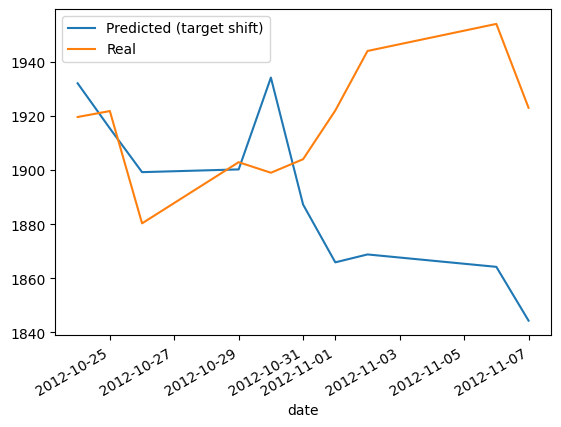

In [15]:
test_predictions_df = pd.DataFrame(
    {"Predicted (target shift)": predictions,
     "Real": test_data[target_col]},
    index=test_data.index
)

test_predictions_df.plot()

- Времени и ресурсов не хватило чтобы сравнить с реализацией модели `auto_arima`, но базово модель должна лучше справляться, потому чтоона включает в себя не только лаговые переменные, но и множество других признаков, а также может справляться с нелинейными изменениями и скачками таргета
- В будущем планируется расширить тестирование модели для большего количества признаков (с учетом экзогенных факторов), тогда потребуется использование PCA, скорее всего
- Небольшой поинт: при использовании экзогенных переменных в том виде в котором они просто есть в датасете, модель начинает хуже прогнозировать. Причина скорее всего в том, что модель обучается на этих признаках, поскольку они помогают с прогнозами, но как только ей нужно делать прогноз на некоторое количество шагов вперед, и у нее нет известных значений этих переменных (они берутся протягиванием последних известных), она теряется.

## Дополнение (кросс-валидация)

In [28]:
def evaluate_catboost_target_shift_cv(
    df: pd.DataFrame,
    target_col: str,
    n_samples: int = 100,
    min_train_size: int = 60,
    test_window: int = 10,
    max_horizon: int = 10,
    val_ratio: float = 0.1,
    random_state: int = 42
) -> pd.DataFrame:

    np.random.seed(random_state)
    max_split_point = len(df) - test_window - max_horizon
    split_points = np.random.randint(min_train_size, max_split_point, size=n_samples)

    all_results = []

    for split_idx, split_point in enumerate(split_points):

        train_full = df.iloc[:split_point]

        # train/val
        val_size = int(len(train_full) * val_ratio)
        if val_size == 0:
            continue

        train_data = train_full.iloc[:-val_size]
        val_data = train_full.iloc[-val_size:]

        for horizon in range(1, max_horizon + 1):
            df_horizon = df.copy()
            df_horizon[f"{target_col}_t{horizon}"] = df_horizon[target_col].shift(-horizon)
            df_horizon = df_horizon.dropna()

            df_horizon_features = df_horizon.drop([target_col, f"{target_col}_t{horizon}"], axis=1, errors="ignore")
            df_horizon = pd.concat([df_horizon_features, df_horizon[[f"{target_col}_t{horizon}"]].rename(
                columns={f"{target_col}_t{horizon}": target_col})], axis=1)

            idx_train = train_data.index.intersection(df_horizon.index)
            idx_val = val_data.index.intersection(df_horizon.index)

            if len(idx_train) == 0:
                continue

            X_train = df_horizon.loc[idx_train].drop(target_col, axis=1)
            y_train = df_horizon.loc[idx_train][target_col]
            X_val = df_horizon.loc[idx_val].drop(target_col, axis=1)
            y_val = df_horizon.loc[idx_val][target_col]

            model = CatBoostRegressor(
                iterations=1000,
                learning_rate=0.05,
                depth=5,
                l2_leaf_reg=3,
                loss_function="MAE",
                eval_metric="MAE",
                early_stopping_rounds=10,
                random_seed=42 + horizon,
                boosting_type="Plain",
                grow_policy="Lossguide",
                random_strength=3,
                leaf_estimation_iterations=20,
                verbose=0
            )

            model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=0)

            x_input = X_train.iloc[[-1]]
            if len(X_val) > horizon - 1:
                x_input = X_val.iloc[[0]]
                y_true = y_val.iloc[horizon - 1]

                y_pred = model.predict(x_input)[0]
                mae = abs(y_true - y_pred)

                all_results.append({
                    "split": split_idx + 1,
                    "horizon": horizon,
                    "mae": mae
                })

        print(f"Обучена модель {split_idx}/{n_samples} - MAE: {mae:.2f}")

    return pd.DataFrame(all_results)


In [29]:
results_df = evaluate_catboost_target_shift_cv(
    df=df_features_ext,
    target_col="LKOH",
    n_samples=100,
    min_train_size=60,
    test_window=10,
    max_horizon=10
)

Обучена модель 0/100 - MAE: 496.05
Обучена модель 1/100 - MAE: 332.35
Обучена модель 2/100 - MAE: 58.21
Обучена модель 3/100 - MAE: 114.25
Обучена модель 4/100 - MAE: 47.00
Обучена модель 5/100 - MAE: 4.06
Обучена модель 6/100 - MAE: 390.36
Обучена модель 7/100 - MAE: 850.26
Обучена модель 8/100 - MAE: 40.66
Обучена модель 9/100 - MAE: 266.47
Обучена модель 10/100 - MAE: 45.13
Обучена модель 11/100 - MAE: 39.46
Обучена модель 12/100 - MAE: 25.08
Обучена модель 13/100 - MAE: 181.39
Обучена модель 14/100 - MAE: 29.42
Обучена модель 15/100 - MAE: 699.41
Обучена модель 16/100 - MAE: 524.38
Обучена модель 17/100 - MAE: 11.94
Обучена модель 18/100 - MAE: 14.14
Обучена модель 19/100 - MAE: 250.84
Обучена модель 20/100 - MAE: 230.43
Обучена модель 21/100 - MAE: 86.02
Обучена модель 22/100 - MAE: 89.46
Обучена модель 23/100 - MAE: 133.21
Обучена модель 24/100 - MAE: 90.51
Обучена модель 25/100 - MAE: 413.06
Обучена модель 26/100 - MAE: 297.27
Обучена модель 27/100 - MAE: 249.77
Обучена модель 2

In [33]:
print(f"Среднее MAE: {results_df['mae'].mean():.2f}")

Среднее MAE: 133.98
